In [1]:
!rm -rf /content/medical-document-ocr-extraction
!git clone https://github.com/tarekmahfoudi/medical-document-ocr-extraction.git

Cloning into 'medical-document-ocr-extraction'...
remote: Enumerating objects: 83, done.
remote: Counting objects: 100% (83/83), done.
remote: Compressing objects: 100% (76/76), done.
remote: Total 83 (delta 16), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (83/83), 4.47 MiB | 14.82 MiB/s, done.
Resolving deltas: 100% (16/16), done.


In [2]:
import os

project_path = "/content/medical-document-ocr-extraction"
raw_path = os.path.join(project_path, "data", "raw", "sample")
processed_path = os.path.join(project_path, "data", "processed", "sample_preprocessed")

os.makedirs(processed_path, exist_ok=True)

image_files = [f for f in os.listdir(raw_path) if f.endswith(".jpg")]

print("Number of images:", len(image_files))
print(image_files[:5])

Number of images: 20
['med_doc_bill_100401_noisy.jpg', 'med_doc_discharge_summary_200434_noisy.jpg', 'med_doc_bill_100407_noisy.jpg', 'med_doc_discharge_summary_200435_noisy.jpg', 'med_doc_discharge_summary_200436_noisy.jpg']


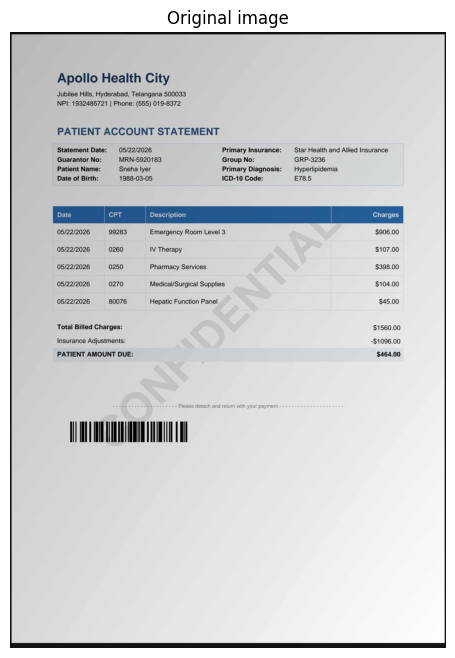

In [3]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = os.path.join(raw_path, image_files[0])
img = Image.open(image_path)

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Original image")
plt.show()

In [5]:
import cv2
import numpy as np

def preprocess_image(input_path, output_path):
    """
    Basic preprocessing for noisy scanned medical document images.

    Steps:
    1. Read image
    2. Convert to grayscale
    3. Apply denoising
    4. Apply adaptive thresholding
    5. Save processed image
    """

    # Read image
    image = cv2.imread(input_path)

    if image is None:
        raise ValueError(f"Could not read image: {input_path}")

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Denoising: reduce small noise
    denoised = cv2.medianBlur(gray, 3)

    # Adaptive thresholding: improve text/background contrast
    thresholded = cv2.adaptiveThreshold(
        denoised,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        31,
        10
    )

    # Save processed image
    cv2.imwrite(output_path, thresholded)

    return gray, denoised, thresholded

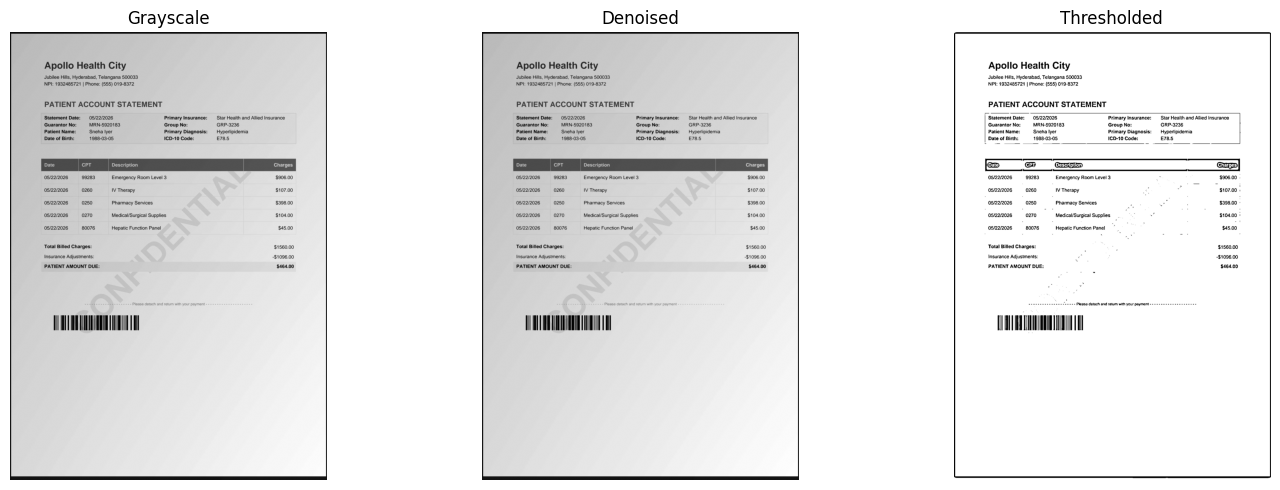

In [6]:
filename = image_files[0]

input_path = os.path.join(raw_path, filename)
output_path = os.path.join(processed_path, filename.replace(".jpg", "_processed.jpg"))

gray, denoised, thresholded = preprocess_image(input_path, output_path)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.title("Grayscale")

plt.subplot(1, 3, 2)
plt.imshow(denoised, cmap="gray")
plt.axis("off")
plt.title("Denoised")

plt.subplot(1, 3, 3)
plt.imshow(thresholded, cmap="gray")
plt.axis("off")
plt.title("Thresholded")

plt.tight_layout()
plt.show()

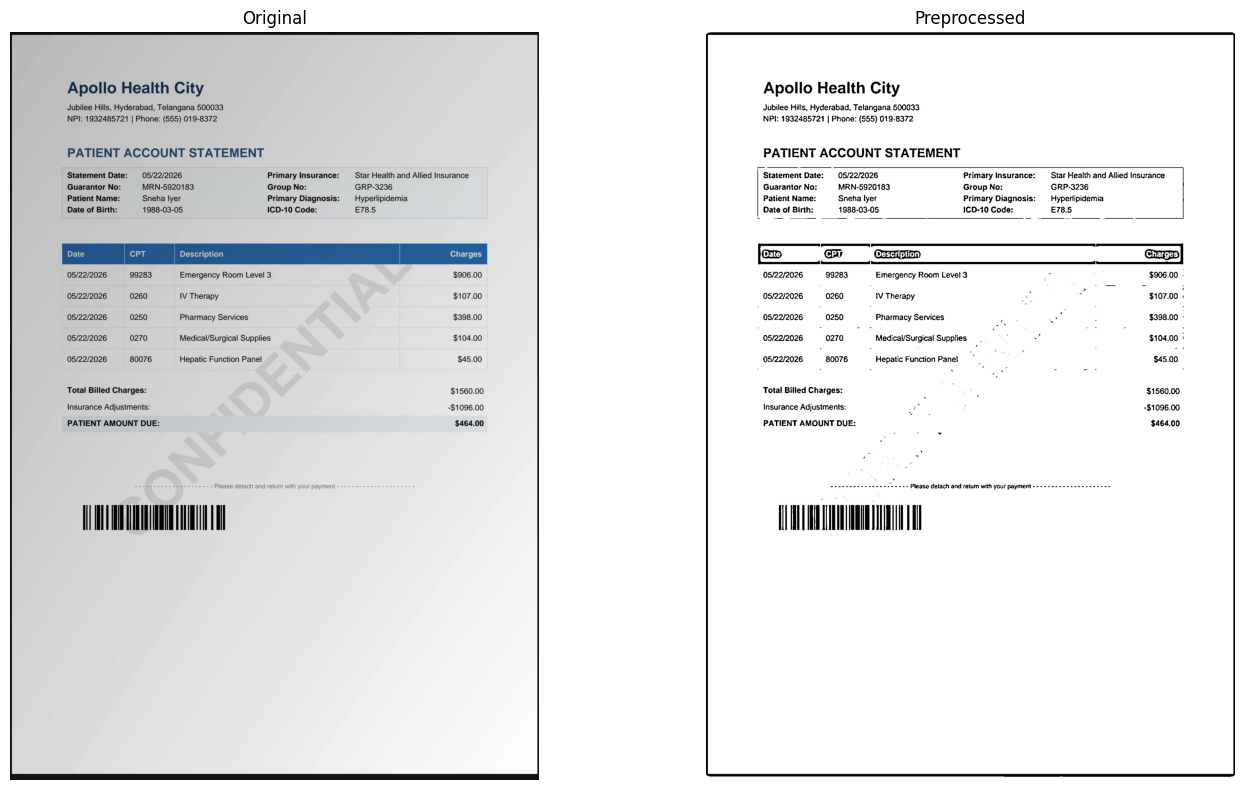

In [7]:
original = Image.open(input_path)
processed = Image.open(output_path)

plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1)
plt.imshow(original)
plt.axis("off")
plt.title("Original")

plt.subplot(1, 2, 2)
plt.imshow(processed, cmap="gray")
plt.axis("off")
plt.title("Preprocessed")

plt.tight_layout()
plt.show()

In [8]:
for filename in image_files:
    input_path = os.path.join(raw_path, filename)
    output_filename = filename.replace(".jpg", "_processed.jpg")
    output_path = os.path.join(processed_path, output_filename)

    preprocess_image(input_path, output_path)

print("Preprocessing completed.")
print("Processed images:", len(os.listdir(processed_path)))

Preprocessing completed.
Processed images: 20


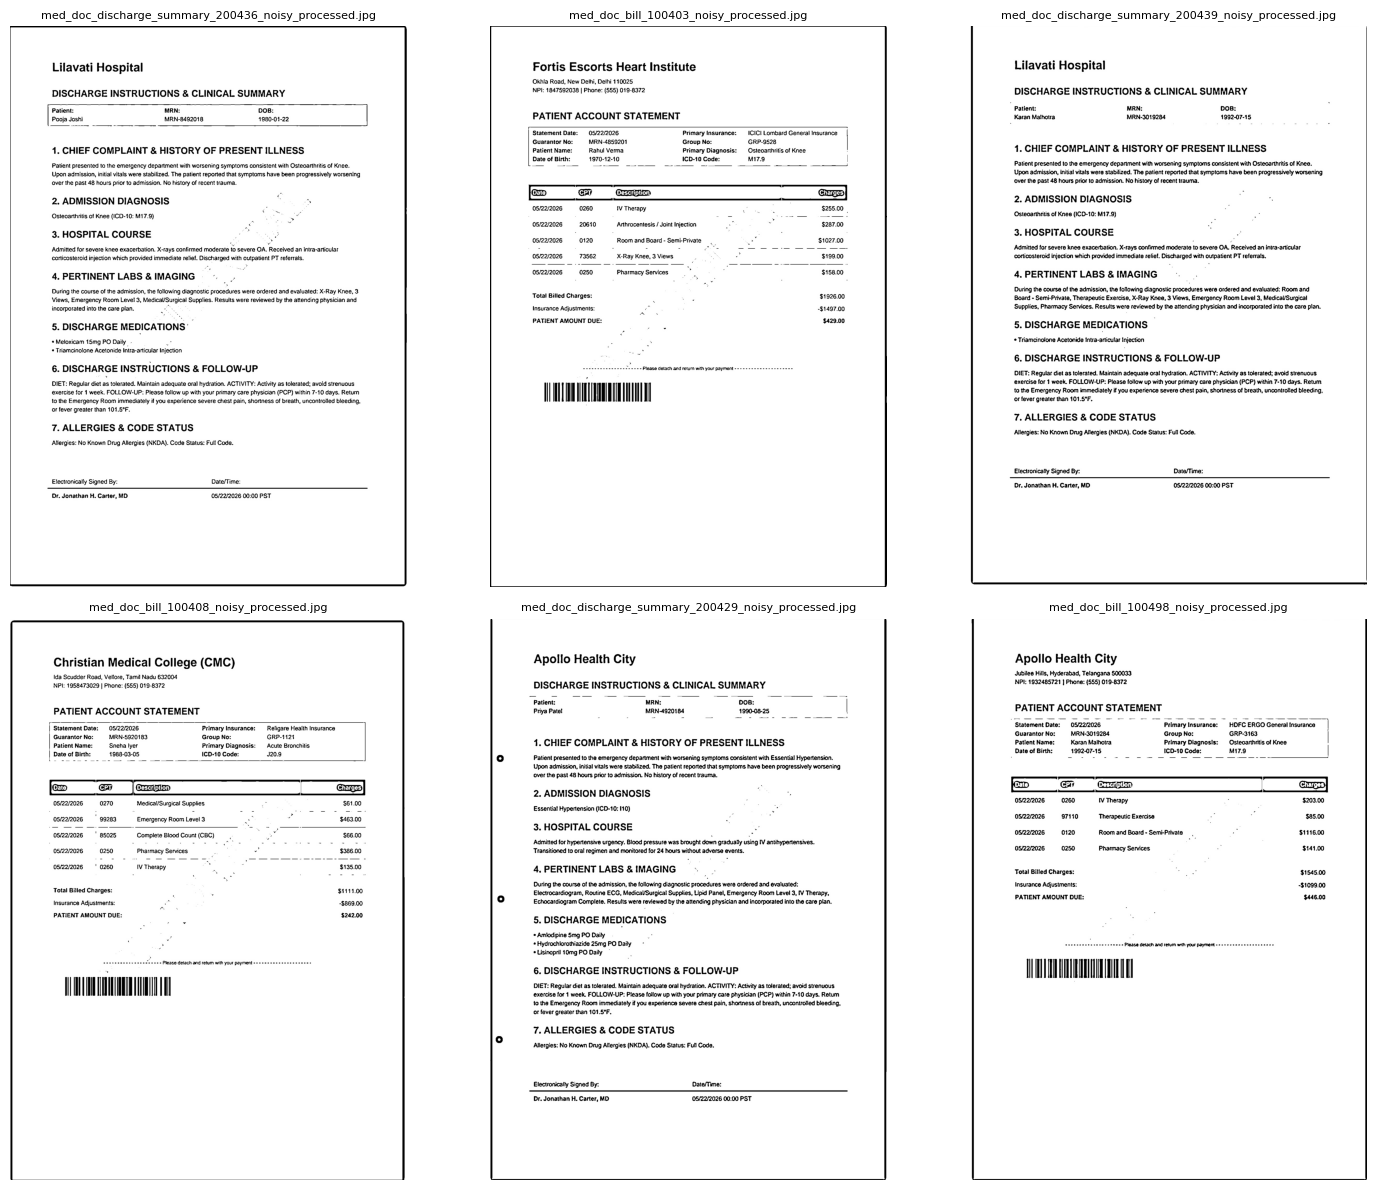

In [9]:
processed_files = [f for f in os.listdir(processed_path) if f.endswith(".jpg")]

plt.figure(figsize=(15, 12))

for i, filename in enumerate(processed_files[:6]):
    image_path = os.path.join(processed_path, filename)
    img = Image.open(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(filename, fontsize=8)

plt.tight_layout()
plt.show()

## Image preprocessing

The goal of this step is to improve the readability of noisy scanned medical document images before OCR.

The preprocessing pipeline includes:

1. conversion to grayscale;
2. denoising using median blur;
3. adaptive thresholding to increase contrast between text and background.

This step is important because OCR engines are sensitive to image quality, noise, contrast and document layout.

However, preprocessing does not always improve OCR results. The effect will be evaluated later by comparing OCR outputs on original and preprocessed images.